# Code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
import os
import pickle
import gc
from tests import (
    build_empirical_distributions,
    compute_hellinger_at_t0,
    build_empirical_distributions,
    plot_nfe_from_distributions,
    plot_vocabulary_distribution_from_result,
    plot_hellinger_across_times,
    plot_nfe_from_folder
    
    )
from main_code import run_diffusion_experiment, add_gillespie_reverse, add_tau_leap_reverse
from saving_experiments import save_samples, load_samples
from collections import Counter, defaultdict


In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Tests - N30

In [ ]:
method_names = [f.replace('.pkl','') for f in os.listdir('methods_N30')
                if f.endswith('.pkl') and f != 'meta.pkl']

result = build_empirical_distributions(
    method_names=method_names,
    k=4,
    methods_dir='methods_N30',
    t=0.0,
    seed=42
)

Selected 4 coordinates: (13, 2, 18, 21)


In [21]:

df_rm = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='random_masking',
    k=4,
    n_bootstrap=1000,
    seed=42
)


Found 96 matching methods.


In [22]:

df_IC = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='informed_corrector',
    k=4,
    n_bootstrap=1000,
    seed=42
)

df_PRISM = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='PRISM',
    k=4,
    n_bootstrap=1000,
    seed=42
)


Found 312 matching methods.
Found 112 matching methods.


In [23]:
max_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmax()]
    ["method_name"]
    .to_list()
)

min_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmin()]
    ["method_name"]
    .to_list()
)

best_IC = df_IC.loc[df_IC.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
worst_IC = df_IC.loc[df_IC.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()
best_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
worst_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()

## Random Corrector

Line 'Tau-Leaping':
  NFE=  31  H=0.0377  [0.0324, 0.0428]  (tau_leap_0.15)
  NFE=  23  H=0.0406  [0.0355, 0.0456]  (tau_leap_0.2)
  NFE=  12  H=0.0435  [0.0387, 0.0485]  (tau_leap_0.4)
  NFE=   9  H=0.0504  [0.0451, 0.0558]  (tau_leap_0.5)
  NFE=   8  H=0.0502  [0.0450, 0.0555]  (tau_leap_0.6)
  NFE=   7  H=0.0510  [0.0460, 0.0566]  (tau_leap_0.7)
  NFE=   6  H=0.0545  [0.0490, 0.0600]  (tau_leap_0.8)
  NFE=   5  H=0.0577  [0.0524, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0684  [0.0628, 0.0738]  (tau_leap_2)
  NFE=   2  H=0.0837  [0.0781, 0.0894]  (tau_leap_3)
  NFE=   2  H=0.0780  [0.0726, 0.0834]  (tau_leap_4)
Line '(Best) Random Masking':
  NFE=   7  H=0.0531  [0.0473, 0.0585]  (tau_leap_1.0_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1)
  NFE=   8  H=0.0503  [0.0451, 0.0559]  (tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.2)
  NFE=   9  H=0.0489  [0.0434, 0.0541]  (tau_leap_0.8_corrector_random_masking_start_2.0_ncorr_1_tauc_0.05)
  NFE=  10  H=0.0522  [0.0470,

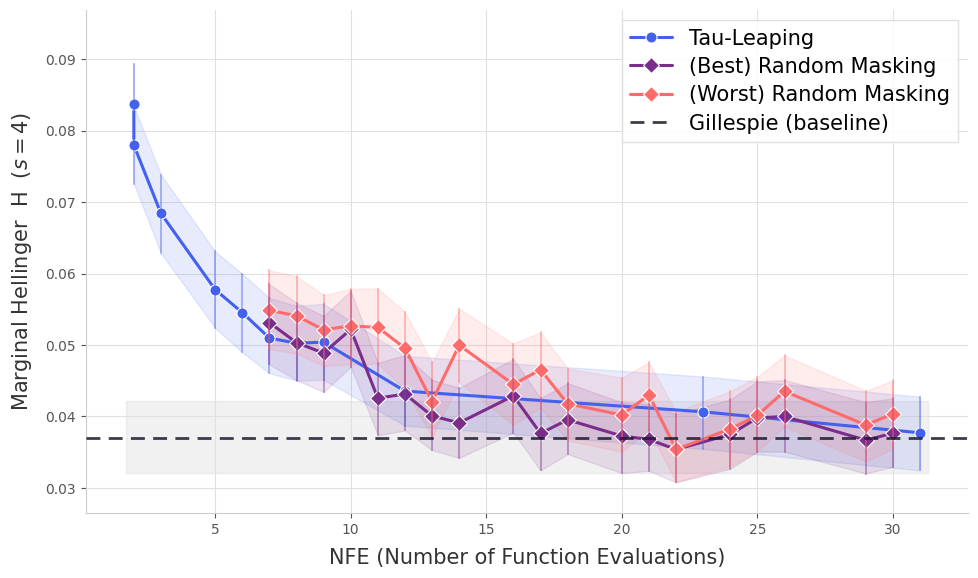

In [7]:


lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    '(Best) Random Masking': min_random_masking,
    '(Worst) Random Masking': max_random_masking,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Selected 4 coordinates: (13, 2, 18, 21)

Line 'Random Masking starts at $t=1.0$':
  NFE=   8  H=0.0506  (tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1)
  NFE=  14  H=0.0421  (tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_4_tauc_0.1)
  NFE=  22  H=0.0354  (tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_8_tauc_0.1)
  NFE=  30  H=0.0399  (tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_12_tauc_0.1)

Line 'gillespie':
  NFE=  30  H=0.0372  (gillespie)


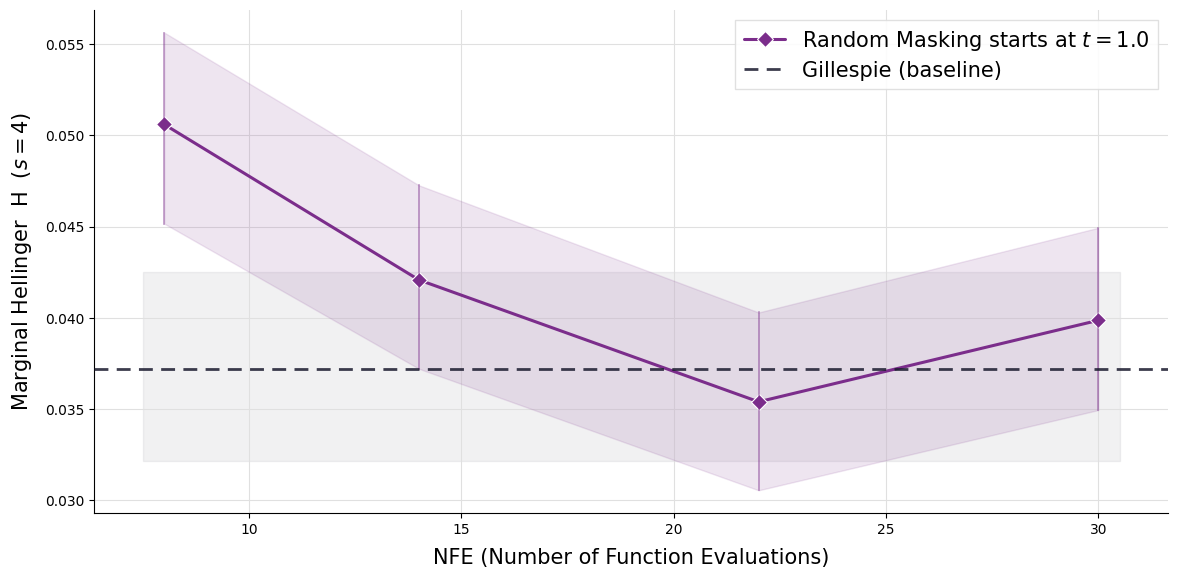

In [24]:


lines = {
    f'Random Masking starts at $t=1.0$': [
        #'tau_leap_0.8',
        'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1',
        'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_4_tauc_0.1',
        'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_8_tauc_0.1',
        'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_12_tauc_0.1',
    ],
    'gillespie': ['gillespie'],
}

_, fig, ax = plot_nfe_from_folder(
    lines=lines,
    k=4,
    methods_dir='methods_N30',
    t=0.0,
    bootstrap=True,
    n_bootstrap=2000,
    seed=42,
)

## Informed Corrector

In [8]:
max_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmax()]
    ["method_name"]
    .to_list()
)

min_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmin()]
    ["method_name"]
    .to_list()
)
# best_DPC = df_DPC.loc[df_DPC.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
# worst_DPC = df_DPC.loc[df_DPC.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()
best_IC = df_IC.loc[df_IC.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
worst_IC = df_IC.loc[df_IC.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()
df_IC_nfe_restricted = df_IC[df_IC["nfe"] <= 35]
best_IC_margin = (
    df_IC_nfe_restricted[df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmin(), "method_name"]
    .to_list()
)

best_IC_no_margin = (
    df_IC_nfe_restricted[~df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmin(), "method_name"]
    .to_list()
)
worst_IC_margin = (
    df_IC_nfe_restricted[df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmax(), "method_name"]
    .to_list()
)

worst_IC_no_margin = (
    df_IC_nfe_restricted[~df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmax(), "method_name"]
    .to_list()
)
best_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
worst_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()

Line 'Tau-Leaping':
  NFE=  31  H=0.0377  [0.0324, 0.0428]  (tau_leap_0.15)
  NFE=  23  H=0.0406  [0.0355, 0.0456]  (tau_leap_0.2)
  NFE=  12  H=0.0435  [0.0387, 0.0485]  (tau_leap_0.4)
  NFE=   9  H=0.0504  [0.0451, 0.0558]  (tau_leap_0.5)
  NFE=   8  H=0.0502  [0.0450, 0.0555]  (tau_leap_0.6)
  NFE=   7  H=0.0510  [0.0460, 0.0566]  (tau_leap_0.7)
  NFE=   6  H=0.0545  [0.0490, 0.0600]  (tau_leap_0.8)
  NFE=   5  H=0.0577  [0.0524, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0684  [0.0628, 0.0738]  (tau_leap_2)
  NFE=   2  H=0.0837  [0.0781, 0.0894]  (tau_leap_3)
  NFE=   2  H=0.0780  [0.0726, 0.0834]  (tau_leap_4)
Line '(Best) Informed Corrector No Margin':
  NFE=   7  H=0.0543  [0.0491, 0.0600]  (tau_leap_1.0_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.8)
  NFE=   8  H=0.0522  [0.0471, 0.0574]  (tau_leap_1.0_corrector_informed_corrector_start_2.0_K_1_ncorr_1_gamma_0.8)
  NFE=   9  H=0.0553  [0.0501, 0.0607]  (tau_leap_1.0_corrector_informed_corrector_start_3.0_K_1_ncorr_1_g

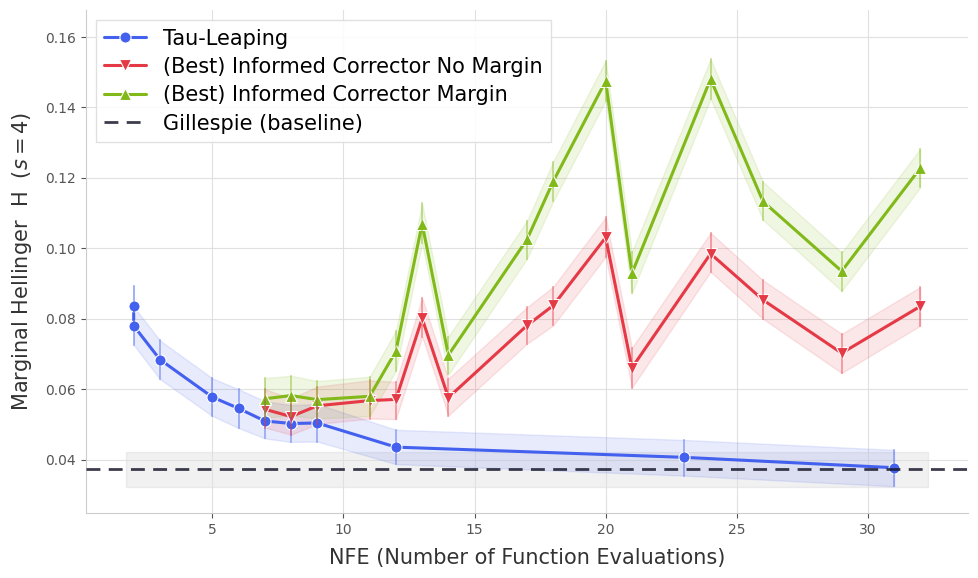

In [9]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    '(Best) Informed Corrector No Margin': best_IC_no_margin,
    # '(Worst) Informed Corrector': worst_IC,
    '(Best) Informed Corrector Margin': best_IC_margin,
    #'(Worst) Informed Corrector Margin': worst_IC_margin,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Line 'Tau-Leaping':
  NFE=  31  H=0.0377  [0.0324, 0.0428]  (tau_leap_0.15)
  NFE=  23  H=0.0406  [0.0355, 0.0456]  (tau_leap_0.2)
  NFE=  12  H=0.0435  [0.0387, 0.0485]  (tau_leap_0.4)
  NFE=   9  H=0.0504  [0.0451, 0.0558]  (tau_leap_0.5)
  NFE=   8  H=0.0502  [0.0450, 0.0555]  (tau_leap_0.6)
  NFE=   7  H=0.0510  [0.0460, 0.0566]  (tau_leap_0.7)
  NFE=   6  H=0.0545  [0.0490, 0.0600]  (tau_leap_0.8)
  NFE=   5  H=0.0577  [0.0524, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0684  [0.0628, 0.0738]  (tau_leap_2)
  NFE=   2  H=0.0837  [0.0781, 0.0894]  (tau_leap_3)
  NFE=   2  H=0.0780  [0.0726, 0.0834]  (tau_leap_4)
Line '(Best) Informed Corrector Margin':
  NFE=   7  H=0.0571  [0.0519, 0.0622]  (tau_leap_1.0_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.8_margin)
  NFE=   8  H=0.0582  [0.0531, 0.0634]  (tau_leap_0.8_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.8_margin)
  NFE=   9  H=0.0570  [0.0518, 0.0627]  (tau_leap_0.8_corrector_informed_corrector_start_2.0_K_

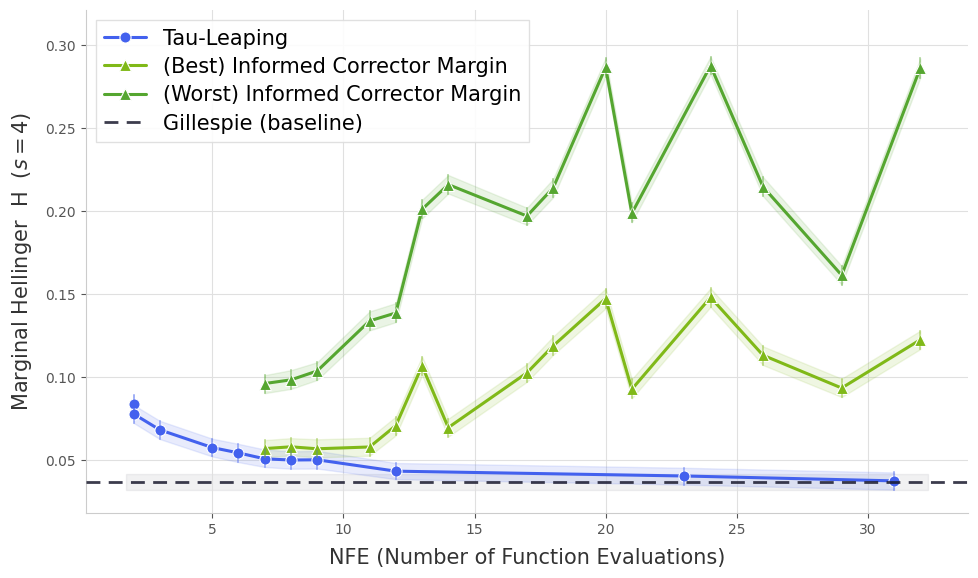

In [10]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    # '(Best) Informed Corrector': best_IC,
    # '(Worst) Informed Corrector': worst_IC,
    '(Best) Informed Corrector Margin': best_IC_margin,
    '(Worst) Informed Corrector Margin': worst_IC_margin,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Line 'Tau-Leaping':
  NFE=  31  H=0.0377  [0.0324, 0.0428]  (tau_leap_0.15)
  NFE=  23  H=0.0406  [0.0355, 0.0456]  (tau_leap_0.2)
  NFE=  12  H=0.0435  [0.0387, 0.0485]  (tau_leap_0.4)
  NFE=   9  H=0.0504  [0.0451, 0.0558]  (tau_leap_0.5)
  NFE=   8  H=0.0502  [0.0450, 0.0555]  (tau_leap_0.6)
  NFE=   7  H=0.0510  [0.0460, 0.0566]  (tau_leap_0.7)
  NFE=   6  H=0.0545  [0.0490, 0.0600]  (tau_leap_0.8)
  NFE=   5  H=0.0577  [0.0524, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0684  [0.0628, 0.0738]  (tau_leap_2)
  NFE=   2  H=0.0837  [0.0781, 0.0894]  (tau_leap_3)
  NFE=   2  H=0.0780  [0.0726, 0.0834]  (tau_leap_4)
Line '(Best) Informed Corrector No Margin':
  NFE=   7  H=0.0543  [0.0491, 0.0600]  (tau_leap_1.0_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.8)
  NFE=   8  H=0.0522  [0.0471, 0.0574]  (tau_leap_1.0_corrector_informed_corrector_start_2.0_K_1_ncorr_1_gamma_0.8)
  NFE=   9  H=0.0553  [0.0501, 0.0607]  (tau_leap_1.0_corrector_informed_corrector_start_3.0_K_1_ncorr_1_g

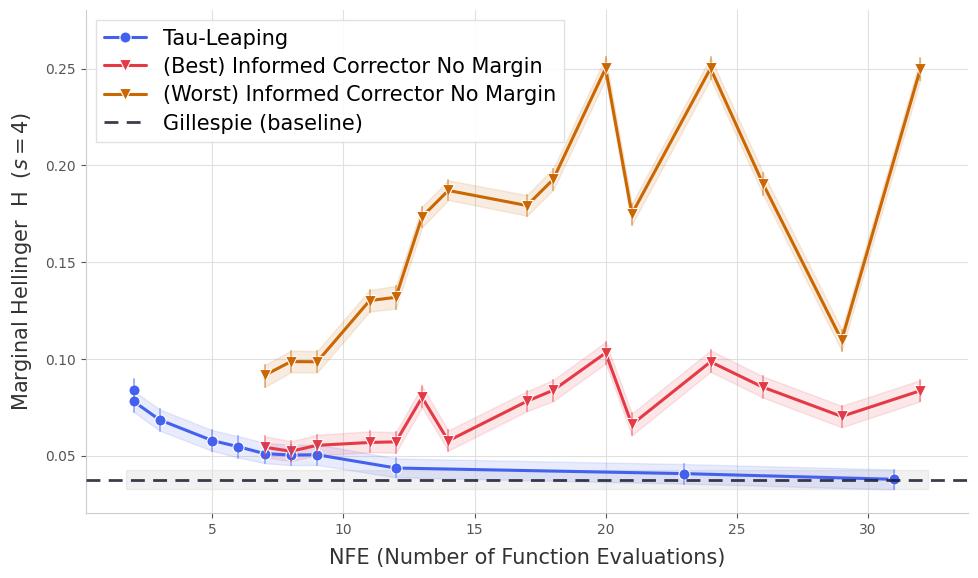

In [11]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    # '(Best) Informed Corrector': best_IC,
    # '(Worst) Informed Corrector': worst_IC,
    '(Best) Informed Corrector No Margin': best_IC_no_margin,
    '(Worst) Informed Corrector No Margin': worst_IC_no_margin,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Plot saved to: vocabulary_distribution.png


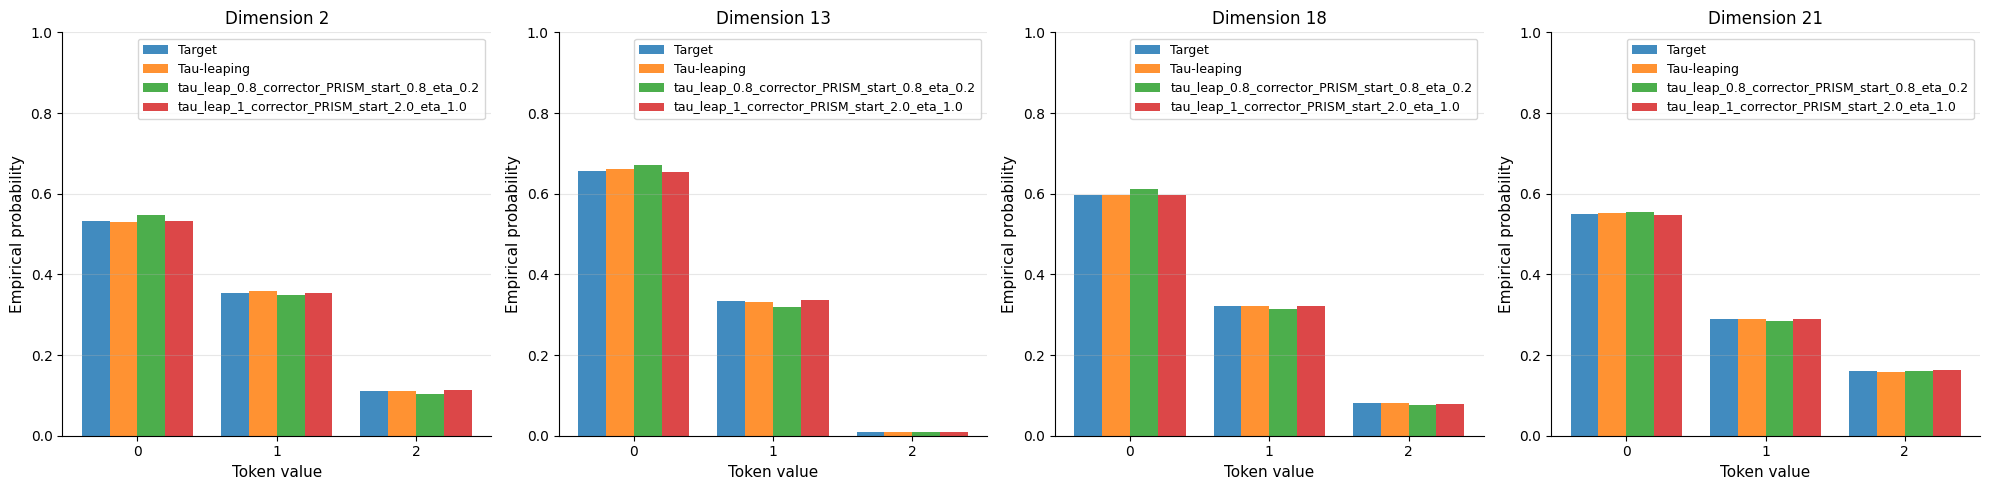

In [13]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.6': 'Tau-leaping',
    'tau_leap_1.0_corrector_informed_corrector_start_2.0_K_1_ncorr_1_gamma_0.8': 'Informed Corrector (best)',
    'tau_leap_0.6_corrector_informed_corrector_start_3.0_K_2_ncorr_12_gamma_1.0_margin': 'Informed Corrector (worst)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[1,0, 2, 3],
    methods=['tau_leap_0.6', 'tau_leap_0.8_corrector_PRISM_start_0.8_eta_0.2', 'tau_leap_1_corrector_PRISM_start_2.0_eta_1.0'],
    L=3,
    labels=labels,
)

## PRISM

Line 'Tau-Leaping':
  NFE=  31  H=0.0377  [0.0324, 0.0428]  (tau_leap_0.15)
  NFE=  23  H=0.0406  [0.0355, 0.0456]  (tau_leap_0.2)
  NFE=  12  H=0.0435  [0.0387, 0.0485]  (tau_leap_0.4)
  NFE=   9  H=0.0504  [0.0451, 0.0558]  (tau_leap_0.5)
  NFE=   8  H=0.0502  [0.0450, 0.0555]  (tau_leap_0.6)
  NFE=   7  H=0.0510  [0.0460, 0.0566]  (tau_leap_0.7)
  NFE=   6  H=0.0545  [0.0490, 0.0600]  (tau_leap_0.8)
  NFE=   5  H=0.0577  [0.0524, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0684  [0.0628, 0.0738]  (tau_leap_2)
  NFE=   2  H=0.0837  [0.0781, 0.0894]  (tau_leap_3)
  NFE=   2  H=0.0780  [0.0726, 0.0834]  (tau_leap_4)
Line '(Best) PRISM':
  NFE=   7  H=0.0608  [0.0551, 0.0664]  (tau_leap_1_corrector_PRISM_start_1.5_eta_0.2)
  NFE=   8  H=0.0602  [0.0548, 0.0651]  (tau_leap_0.8_corrector_PRISM_start_0.8_eta_0.2)
  NFE=   9  H=0.0592  [0.0542, 0.0645]  (tau_leap_0.8_corrector_PRISM_start_2.0_eta_0.2)
  NFE=  10  H=0.0573  [0.0518, 0.0628]  (tau_leap_0.8_corrector_PRISM_start_2.5_eta_0.2)
  NFE= 

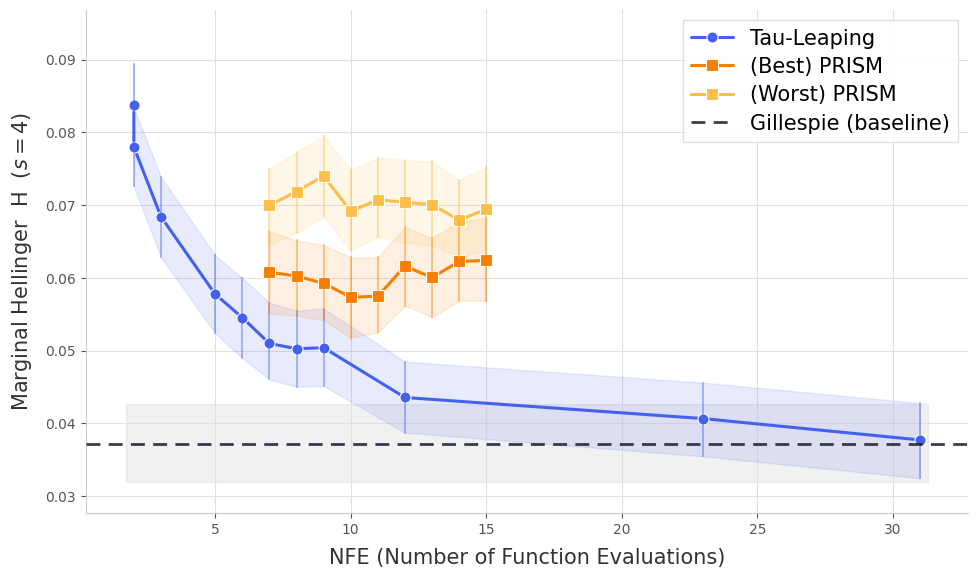

In [14]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    '(Best) PRISM': best_PRISM,
    '(Worst) PRISM': worst_PRISM,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Plot saved to: vocabulary_distribution.png


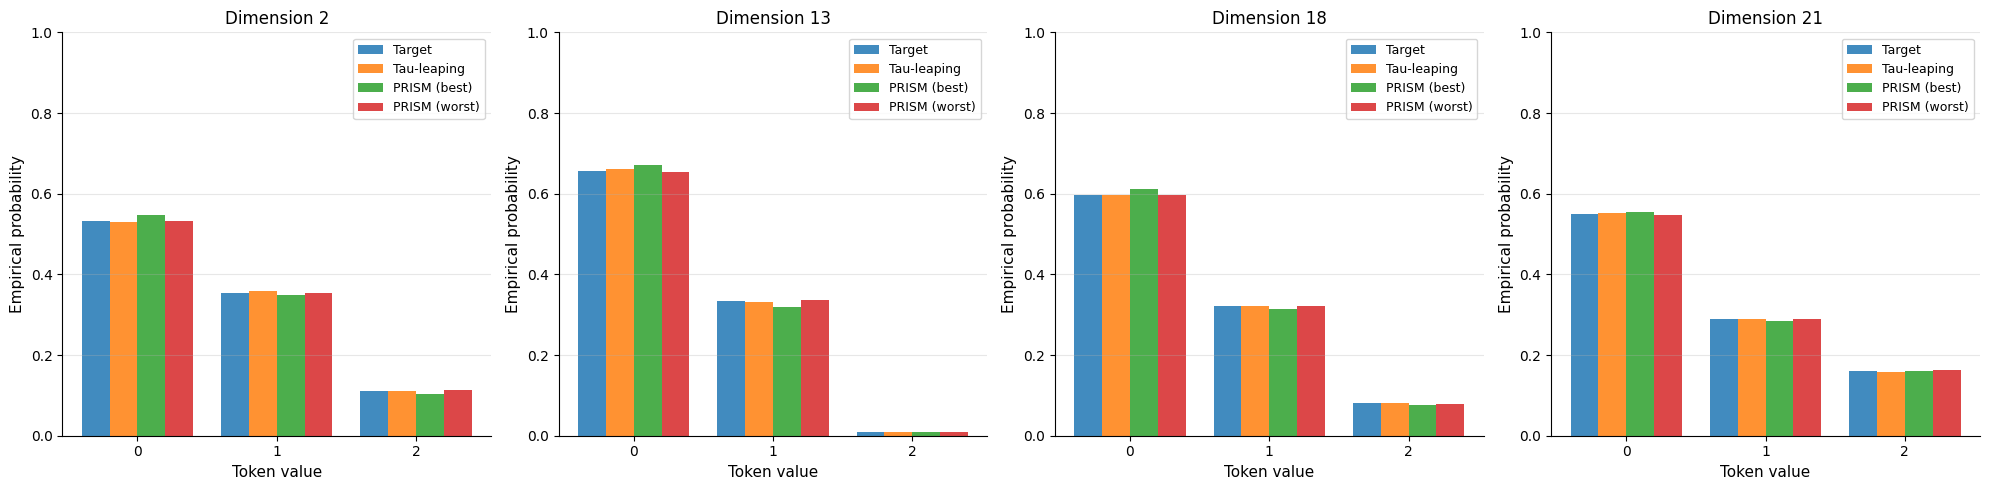

In [15]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.6': 'Tau-leaping',
    'tau_leap_0.8_corrector_PRISM_start_0.8_eta_0.2': 'PRISM (best)',
    'tau_leap_1_corrector_PRISM_start_2.0_eta_1.0': 'PRISM (worst)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[1,0, 2, 3],
    methods=['tau_leap_0.6', 'tau_leap_0.8_corrector_PRISM_start_0.8_eta_0.2', 'tau_leap_1_corrector_PRISM_start_2.0_eta_1.0'],
    L=3,
    labels=labels,
)

Plot saved to: vocabulary_distribution.png


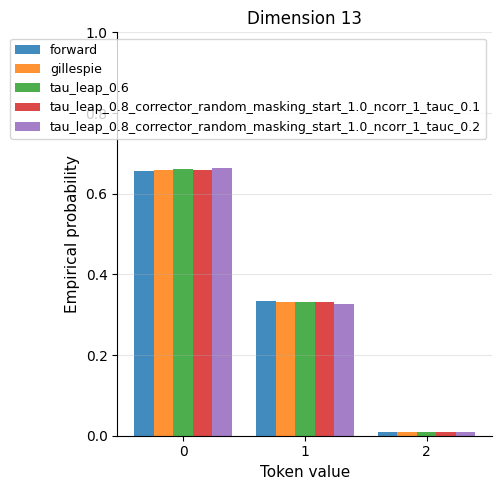

In [17]:
plot_vocabulary_distribution_from_result(
    result=result,
    indices=[0],
    methods=['gillespie', 'tau_leap_0.6', 'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1','tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2'],
    L=3,
)

Plot saved to: vocabulary_distribution.png


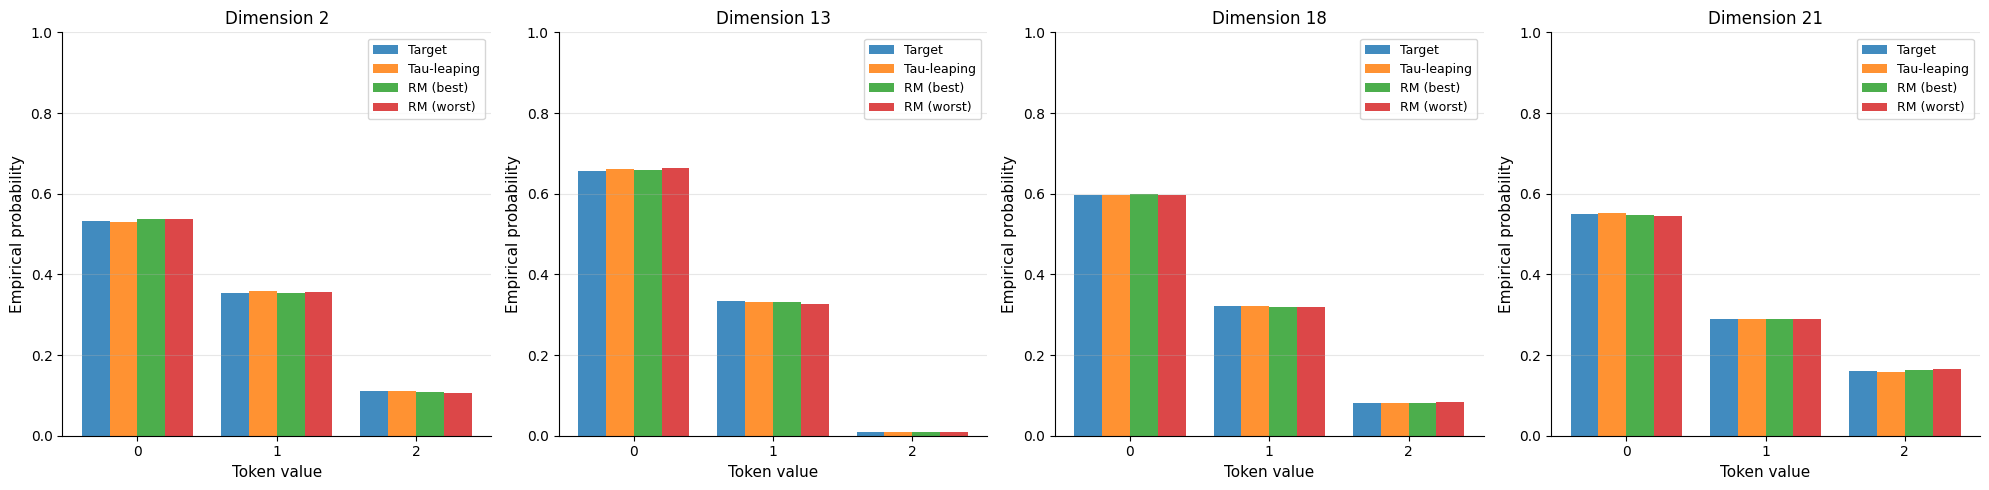

In [18]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.6': 'Tau-leaping',
    'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1': 'RM (best)',
    'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2': 'RM (worst)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[1,0, 2, 3],
    methods=['tau_leap_0.6', 'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1', 'tau_leap_0.8_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2'],
    L=3,
    labels=labels,
)

# Tests - N200

In [25]:
seed = 0

method_names = [f.replace('.pkl','') for f in os.listdir('methods_N200')
                if f.endswith('.pkl') and f != 'meta.pkl']

result = build_empirical_distributions(
    method_names=method_names,
    k=4,
    methods_dir='methods_N200',
    t=0.0,
    seed=seed
)

Selected 4 coordinates: (53, 101, 167, 126)


In [26]:
df_rm = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='random_masking',
    k=4,
    n_bootstrap=1000,
    seed=seed
)

df_IC = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='informed_corrector',
    k=4,
    n_bootstrap=1000,
    seed=42
)
df_PRISM = compute_hellinger_at_t0(
    result=result,
    corrector_present=True,
    corrector_name='PRISM',
    k=4,
    n_bootstrap=1000,
    seed=42
)


Found 64 matching methods.
Found 163 matching methods.
Found 84 matching methods.


In [27]:
max_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmax()]
    ["method_name"]
    .to_list()
)

min_random_masking = (
    df_rm[df_rm["nfe"] <= 30]
    .loc[lambda d: d.groupby("nfe")["hellinger_mean"].idxmin()]
    ["method_name"]
    .to_list()
)

df_IC_nfe_restricted = df_IC[df_IC["nfe"] <= 35]
best_IC_margin = (
    df_IC_nfe_restricted[df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmin(), "method_name"]
    .to_list()
)

best_IC_no_margin = (
    df_IC_nfe_restricted[~df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmin(), "method_name"]
    .to_list()
)
worst_IC_margin = (
    df_IC_nfe_restricted[df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmax(), "method_name"]
    .to_list()
)

worst_IC_no_margin = (
    df_IC_nfe_restricted[~df_IC_nfe_restricted["method_name"].str.contains("margin", case=False, na=False)]
    .loc[lambda x: x.groupby("nfe")["hellinger_mean"].idxmax(), "method_name"]
    .to_list()
)
best_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmin()]["method_name"].to_list()
worst_PRISM = df_PRISM.loc[df_PRISM.groupby('nfe')['hellinger_mean'].idxmax()]["method_name"].to_list()

## Random Masking 

Line 'Tau-Leaping':
  NFE=  31  H=0.0355  [0.0318, 0.0409]  (tau_leap_0.15)
  NFE=  23  H=0.0377  [0.0326, 0.0422]  (tau_leap_0.2)
  NFE=  12  H=0.0392  [0.0347, 0.0440]  (tau_leap_0.4)
  NFE=   9  H=0.0442  [0.0379, 0.0502]  (tau_leap_0.5)
  NFE=   8  H=0.0453  [0.0397, 0.0508]  (tau_leap_0.6)
  NFE=   7  H=0.0480  [0.0421, 0.0534]  (tau_leap_0.7)
  NFE=   6  H=0.0522  [0.0462, 0.0579]  (tau_leap_0.8)
  NFE=   5  H=0.0573  [0.0515, 0.0631]  (tau_leap_1)
  NFE=   3  H=0.0892  [0.0840, 0.0955]  (tau_leap_2)
  NFE=   2  H=0.0862  [0.0799, 0.0920]  (tau_leap_3)
  NFE=   2  H=0.1201  [0.1141, 0.1260]  (tau_leap_4)
Line '(Best) Random Masking':
  NFE=   7  H=0.0423  [0.0368, 0.0473]  (tau_leap_1.0_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2)
  NFE=   8  H=0.0420  [0.0365, 0.0463]  (tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.2)
  NFE=   9  H=0.0427  [0.0380, 0.0476]  (tau_leap_1.0_corrector_random_masking_start_3.0_ncorr_1_tauc_0.2)
  NFE=  10  H=0.0420  [0.0374, 

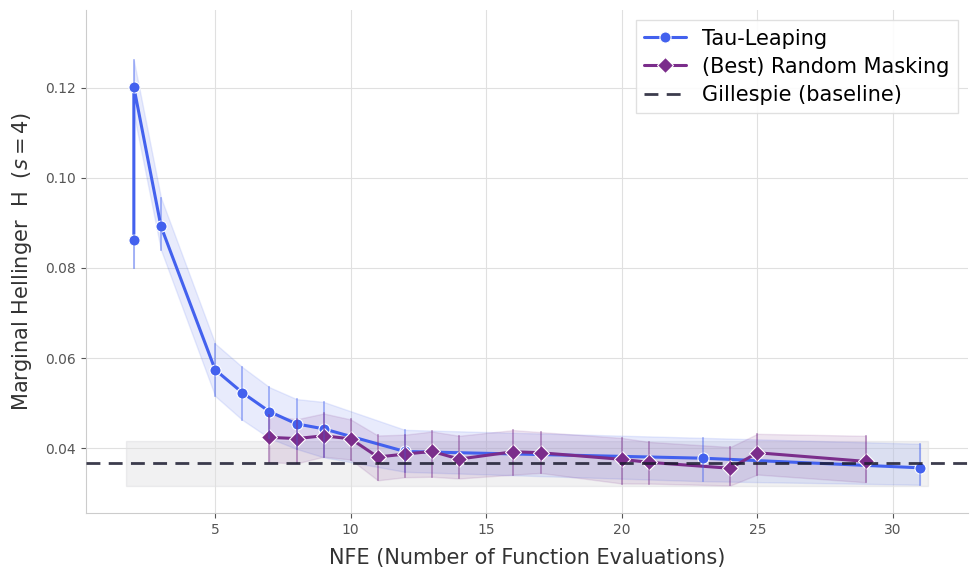

In [28]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    '(Best) Random Masking': min_random_masking,
     #   '(Worst) Random Masking': max_random_masking,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=100,
    alpha=0.05,
    seed=seed
)

Plot saved to: vocabulary_distribution.png


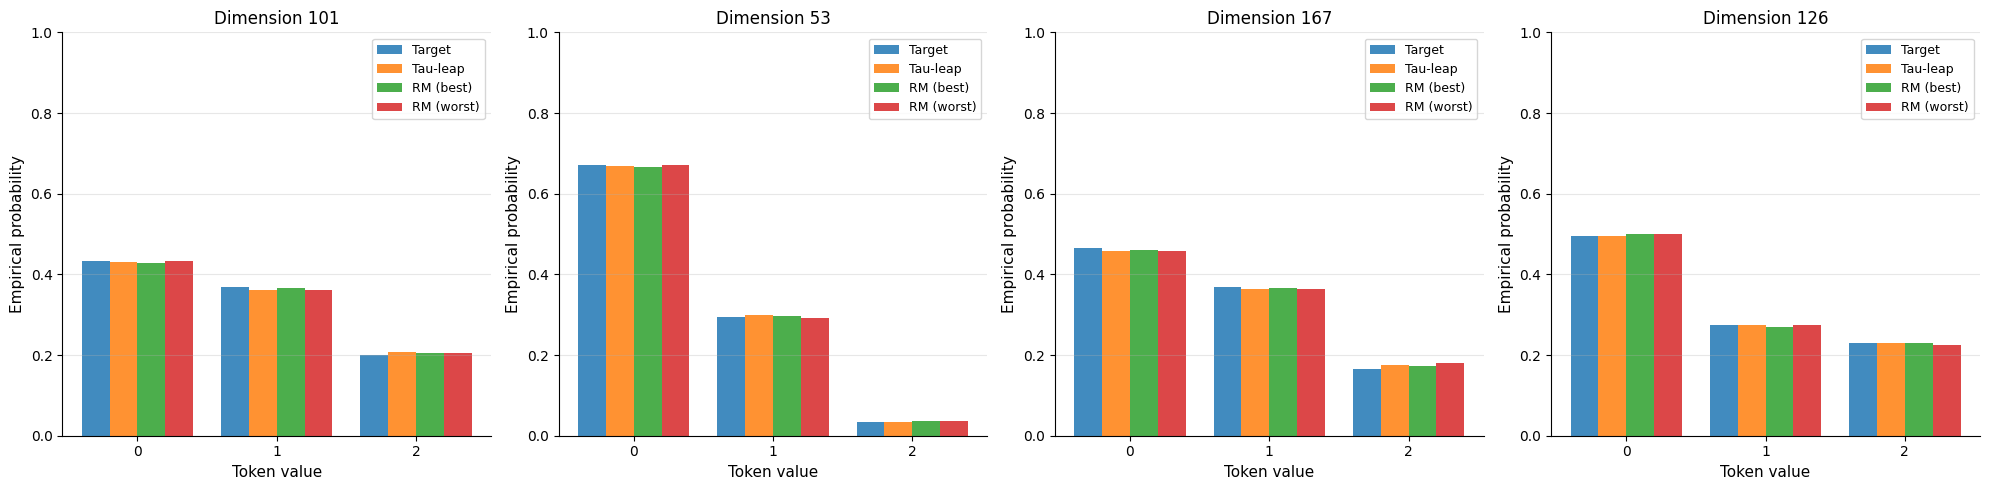

In [29]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.6': 'Tau-leap',
    'tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.2': 'RM (best)',
    'tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.05': 'RM (worst)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[1,0, 2, 3],
    methods=['tau_leap_0.6', 'tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.2', 'tau_leap_1.0_corrector_random_masking_start_2.0_ncorr_1_tauc_0.05'],
    L=3,
    labels=labels,
)

## Informed Corrector

Line 'Tau-Leaping':
  NFE=  31  H=0.0360  [0.0309, 0.0409]  (tau_leap_0.15)
  NFE=  23  H=0.0372  [0.0326, 0.0423]  (tau_leap_0.2)
  NFE=  12  H=0.0390  [0.0337, 0.0442]  (tau_leap_0.4)
  NFE=   9  H=0.0441  [0.0386, 0.0496]  (tau_leap_0.5)
  NFE=   8  H=0.0455  [0.0404, 0.0507]  (tau_leap_0.6)
  NFE=   7  H=0.0481  [0.0431, 0.0539]  (tau_leap_0.7)
  NFE=   6  H=0.0519  [0.0467, 0.0578]  (tau_leap_0.8)
  NFE=   5  H=0.0575  [0.0523, 0.0630]  (tau_leap_1)
  NFE=   3  H=0.0894  [0.0835, 0.0953]  (tau_leap_2)
  NFE=   2  H=0.0859  [0.0806, 0.0917]  (tau_leap_3)
  NFE=   2  H=0.1201  [0.1145, 0.1257]  (tau_leap_4)
Line '(Best) Informed Corrector No Margin':
  NFE=   7  H=0.0407  [0.0353, 0.0458]  (tau_leap_1.0_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.5)
  NFE=   8  H=0.0416  [0.0364, 0.0466]  (tau_leap_1.0_corrector_informed_corrector_start_2.0_K_2_ncorr_1_gamma_0.8)
  NFE=   9  H=0.0412  [0.0363, 0.0464]  (tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_g

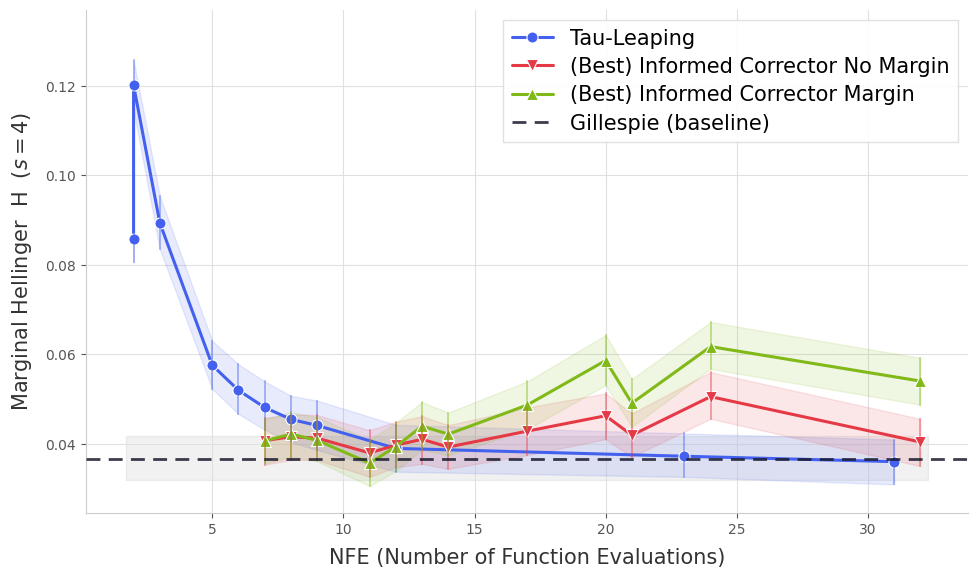

In [30]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    # '(Best) Informed Corrector': best_IC,
    # '(Worst) Informed Corrector': worst_IC,
    '(Best) Informed Corrector No Margin': best_IC_no_margin,
    '(Best) Informed Corrector Margin': best_IC_margin,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Plot saved to: vocabulary_distribution.png


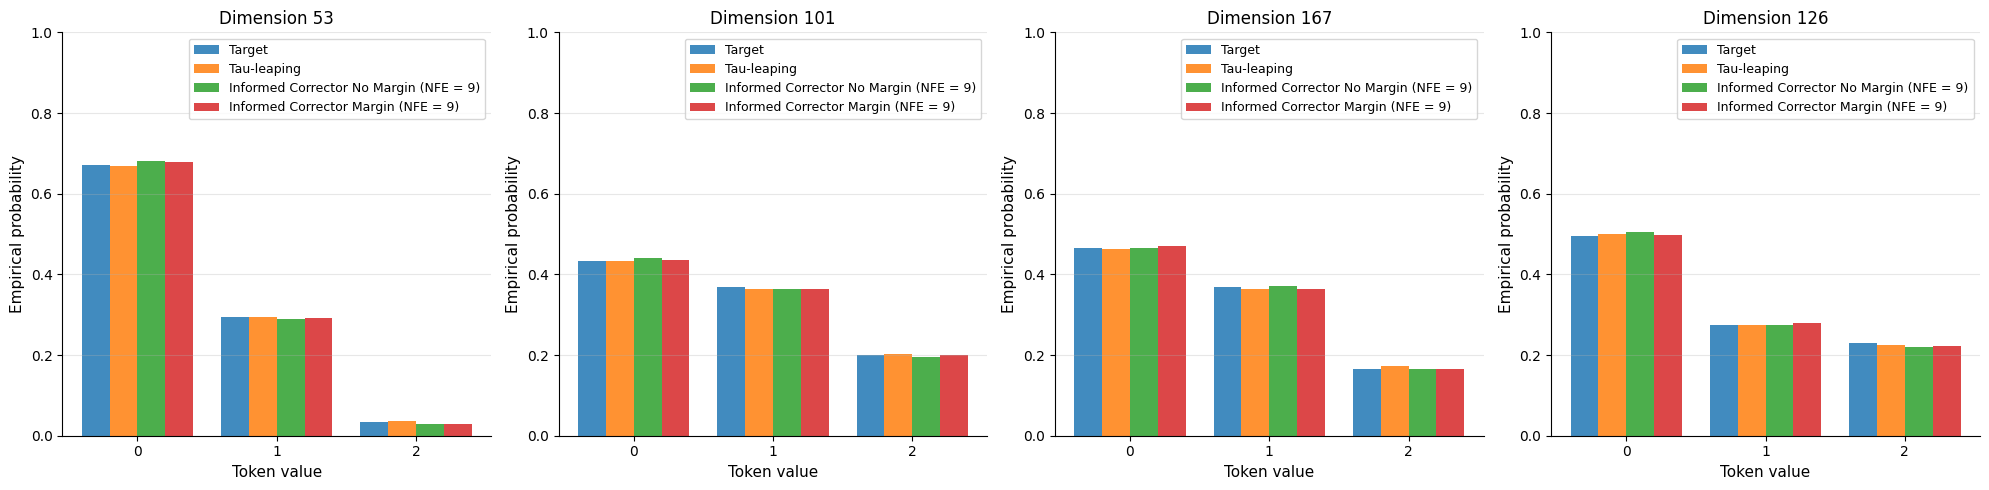

In [31]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.5': 'Tau-leaping',
    'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.5': 'Informed Corrector No Margin (NFE = 9)',
    'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_1_ncorr_1_gamma_0.5_margin': 'Informed Corrector Margin (NFE = 9)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[0, 1,2,3],
    methods=['tau_leap_0.5', 'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.5', 'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_1_ncorr_1_gamma_0.5_margin'],
    L=3,
    labels=labels,
)

Line 'Tau-Leaping':
  NFE=  31  H=0.0360  [0.0309, 0.0409]  (tau_leap_0.15)
  NFE=  23  H=0.0372  [0.0326, 0.0423]  (tau_leap_0.2)
  NFE=  12  H=0.0390  [0.0337, 0.0442]  (tau_leap_0.4)
  NFE=   9  H=0.0441  [0.0386, 0.0496]  (tau_leap_0.5)
  NFE=   8  H=0.0455  [0.0404, 0.0507]  (tau_leap_0.6)
  NFE=   7  H=0.0481  [0.0431, 0.0539]  (tau_leap_0.7)
  NFE=   6  H=0.0519  [0.0467, 0.0578]  (tau_leap_0.8)
  NFE=   5  H=0.0575  [0.0523, 0.0630]  (tau_leap_1)
  NFE=   3  H=0.0894  [0.0835, 0.0953]  (tau_leap_2)
  NFE=   2  H=0.0859  [0.0806, 0.0917]  (tau_leap_3)
  NFE=   2  H=0.1201  [0.1145, 0.1257]  (tau_leap_4)
Line '(Best) Informed Corrector No Margin':
  NFE=   7  H=0.0407  [0.0353, 0.0458]  (tau_leap_1.0_corrector_informed_corrector_start_1.0_K_1_ncorr_1_gamma_0.5)
  NFE=   8  H=0.0416  [0.0364, 0.0466]  (tau_leap_1.0_corrector_informed_corrector_start_2.0_K_2_ncorr_1_gamma_0.8)
  NFE=   9  H=0.0412  [0.0363, 0.0464]  (tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_g

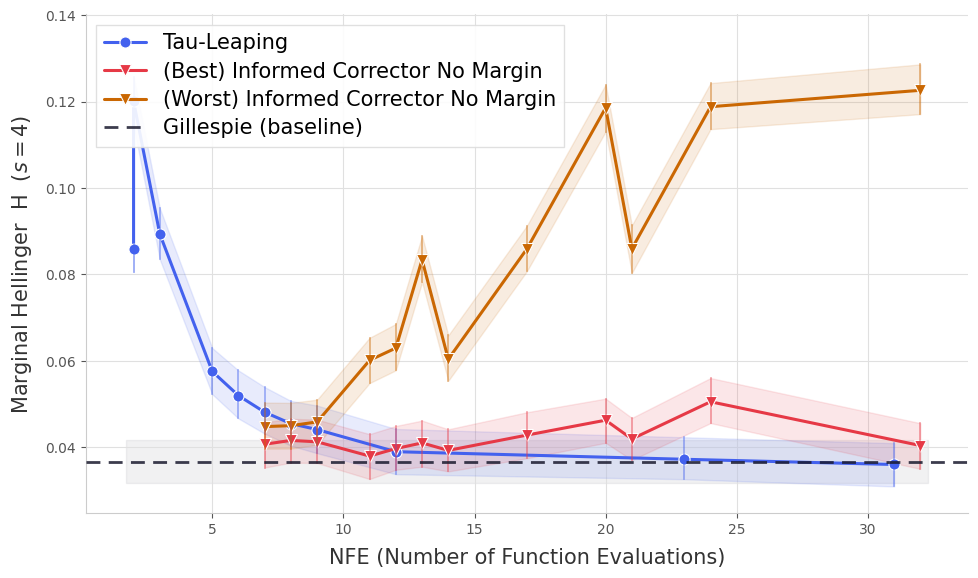

In [32]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    # '(Best) Informed Corrector': best_IC,
    # '(Worst) Informed Corrector': worst_IC,
    '(Best) Informed Corrector No Margin': best_IC_no_margin,
    '(Worst) Informed Corrector No Margin': worst_IC_no_margin,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

In [ ]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.5': 'Tau-leaping (NFE = 9)',
    'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.5': 'Best IC No Margin (NFE = 9)',
    'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.2': 'Worst IC No Margin (NFE = 9)',
    'tau_leap_0.6_corrector_informed_corrector_start_2.0_K_1_ncorr_4_gamma_0.8': 'Best IC No Margin (NFE = 24)',
    'tau_leap_0.6_corrector_informed_corrector_start_2.0_K_2_ncorr_4_gamma_0.2': 'Worst IC No Margin (NFE = 24)'
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[1,0, 2, 3],
    methods=['tau_leap_0.5', 'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.5', 'tau_leap_1.0_corrector_informed_corrector_start_3.0_K_2_ncorr_1_gamma_0.2', 'tau_leap_0.6_corrector_informed_corrector_start_2.0_K_1_ncorr_4_gamma_0.8','tau_leap_0.6_corrector_informed_corrector_start_2.0_K_2_ncorr_4_gamma_0.2'],
    L=3,
    labels=labels,
)

## PRISM

Line 'Tau-Leaping':
  NFE=  31  H=0.0360  [0.0309, 0.0409]  (tau_leap_0.15)
  NFE=  23  H=0.0372  [0.0326, 0.0423]  (tau_leap_0.2)
  NFE=  12  H=0.0390  [0.0337, 0.0442]  (tau_leap_0.4)
  NFE=   9  H=0.0441  [0.0386, 0.0496]  (tau_leap_0.5)
  NFE=   8  H=0.0455  [0.0404, 0.0507]  (tau_leap_0.6)
  NFE=   7  H=0.0481  [0.0431, 0.0539]  (tau_leap_0.7)
  NFE=   6  H=0.0519  [0.0467, 0.0578]  (tau_leap_0.8)
  NFE=   5  H=0.0575  [0.0523, 0.0630]  (tau_leap_1)
  NFE=   3  H=0.0894  [0.0835, 0.0953]  (tau_leap_2)
  NFE=   2  H=0.0859  [0.0806, 0.0917]  (tau_leap_3)
  NFE=   2  H=0.1201  [0.1145, 0.1257]  (tau_leap_4)
Line '(Best) PRISM':
  NFE=   7  H=0.0510  [0.0456, 0.0564]  (tau_leap_1.0_corrector_PRISM_start_0.8_eta_0.2)
  NFE=   8  H=0.0402  [0.0349, 0.0454]  (tau_leap_0.8_corrector_PRISM_start_0.8_eta_0.2)
  NFE=   9  H=0.0478  [0.0424, 0.0530]  (tau_leap_0.8_corrector_PRISM_start_2.0_eta_0.2)
  NFE=  10  H=0.0390  [0.0344, 0.0440]  (tau_leap_0.6_corrector_PRISM_start_0.8_eta_0.8)
  NFE

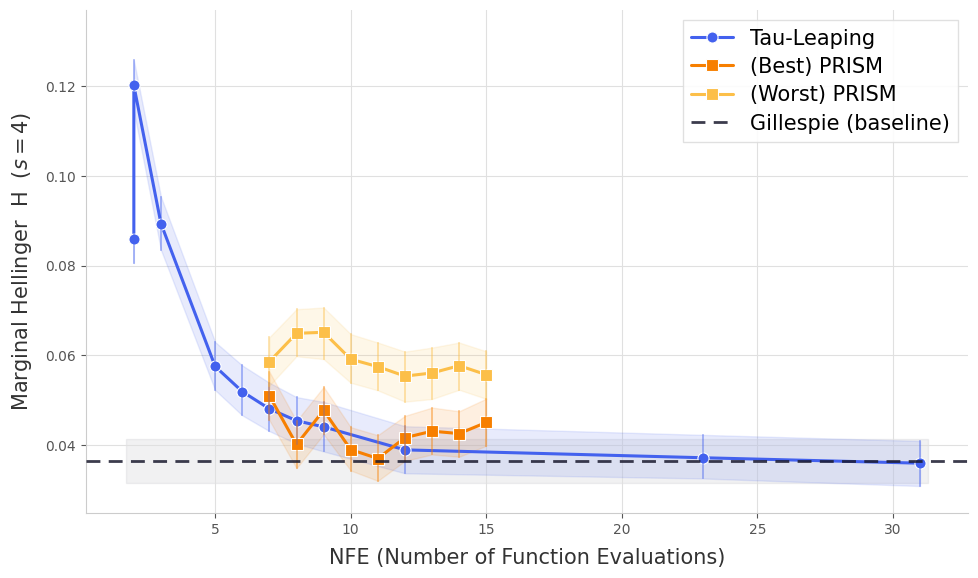

In [33]:
lines = {
    'Tau-Leaping':       ['tau_leap_0.15','tau_leap_0.2', 'tau_leap_0.4','tau_leap_0.5','tau_leap_0.6', 'tau_leap_0.7','tau_leap_0.8', 'tau_leap_1', 'tau_leap_2', 'tau_leap_3', 'tau_leap_4'],
   
    '(Best) PRISM': best_PRISM,
    '(Worst) PRISM': worst_PRISM,

   'gillespie':     ['gillespie'],
}

results, fig, ax = plot_nfe_from_distributions(
    result=result,
    lines=lines,
    n_bootstrap=1000,
    alpha=0.05,
    seed=42
)

Plot saved to: vocabulary_distribution.png


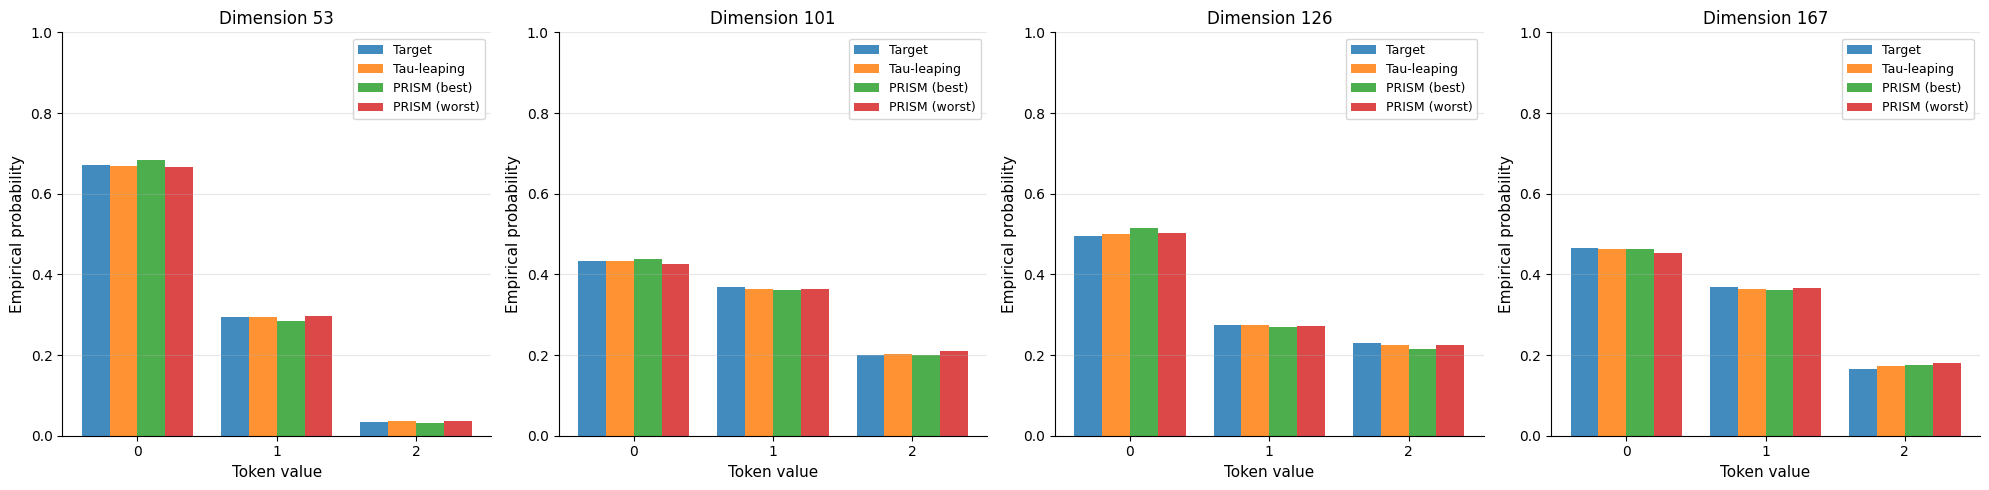

In [34]:
labels = {
    'forward':      'Target',
    'gillespie':    'Gillespie',
    'tau_leap_0.5': 'Tau-leaping',
    'tau_leap_0.8_corrector_PRISM_start_2.0_eta_0.2': 'PRISM (best)',
    'tau_leap_1.0_corrector_PRISM_start_3.0_eta_1.0': 'PRISM (worst)',
}

plot_vocabulary_distribution_from_result(
    result=result,
    indices=[0,1, 3, 2],
    methods=['tau_leap_0.5', 'tau_leap_0.8_corrector_PRISM_start_2.0_eta_0.2', 'tau_leap_1.0_corrector_PRISM_start_3.0_eta_1.0'],
    L=3,
    labels=labels,
)